# 04 - Improved CNN for Chinese Herbal Medicine Classification (PyTorch)

This notebook trains an **improved CNN** on **Dataset 1**.

It follows a clear deep learning workflow similar to classroom examples:
1. Load and inspect data
2. Apply normalization and augmentation
3. Build an improved CNN
4. Train with validation monitoring
5. Save the best model and reports
6. Evaluate on the test set
7. Visualize results

Compared with the baseline CNN, this version includes:
- Batch Normalization
- Adaptive Average Pooling
- Stronger augmentation
- Weight decay
- Label smoothing
- Clear file naming for outputs


In [1]:
# Install packages if needed
# pip install torch torchvision torchaudio
# pip install pandas matplotlib scikit-learn pillow tqdm

In [2]:
# Imports
import os
import json
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

PyTorch version: 2.7.1+cu128
CUDA available: True
GPU name: NVIDIA GeForce RTX 2060


In [3]:
# Optional: display Chinese class names correctly on Windows
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "SimSun", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

In [4]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [5]:
# Paths
PROJECT_ROOT = Path(r"I:\DeepLearning\ChineseHerb_Identify")

DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "herb50_dataset_1" / "split_dataset"
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"
TEST_DIR = DATA_ROOT / "test"

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
REPORTS_DIR = RESULTS_DIR / "reports"
MODELS_DIR = PROJECT_ROOT / "models" / "cnn"

for p in [FIGURES_DIR, REPORTS_DIR, MODELS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR  :", VAL_DIR)
print("TEST_DIR :", TEST_DIR)

TRAIN_DIR: I:\DeepLearning\ChineseHerb_Identify\data\raw\herb50_dataset_1\split_dataset\train
VAL_DIR  : I:\DeepLearning\ChineseHerb_Identify\data\raw\herb50_dataset_1\split_dataset\val
TEST_DIR : I:\DeepLearning\ChineseHerb_Identify\data\raw\herb50_dataset_1\split_dataset\test


In [6]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [7]:
# Hyperparameters
IMG_SIZE = 160
BATCH_SIZE = 64
EPOCHS = 45
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0   # Safer for Windows notebook
PATIENCE = 5

In [8]:
# Data transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(12),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [9]:
# Datasets
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=eval_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("First 10 classes:", class_names[:10])

Number of classes: 50
First 10 classes: ['乌梅', '侧柏叶', '北沙参块', '北沙参条', '半夏', '地龙', '夏枯草', '大血藤', '小茴香', '巴戟天']


In [10]:
# Save class mapping
improved_cnn_class_mapping_df = pd.DataFrame({
    "class_id": list(range(len(class_names))),
    "class_name_cn": class_names
})

improved_cnn_class_mapping_path = REPORTS_DIR / "improved_cnn_pytorch_class_mapping.csv"
improved_cnn_class_mapping_df.to_csv(improved_cnn_class_mapping_path, index=False, encoding="utf-8-sig")

print("Saved:", improved_cnn_class_mapping_path)
improved_cnn_class_mapping_df.head()

Saved: I:\DeepLearning\ChineseHerb_Identify\results\reports\improved_cnn_pytorch_class_mapping.csv


,class_id,class_name_cn
0,0,乌梅
1,1,侧柏叶
2,2,北沙参块
3,3,北沙参条
4,4,半夏


In [11]:
# Dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches: 779
Val batches  : 98
Test batches : 98


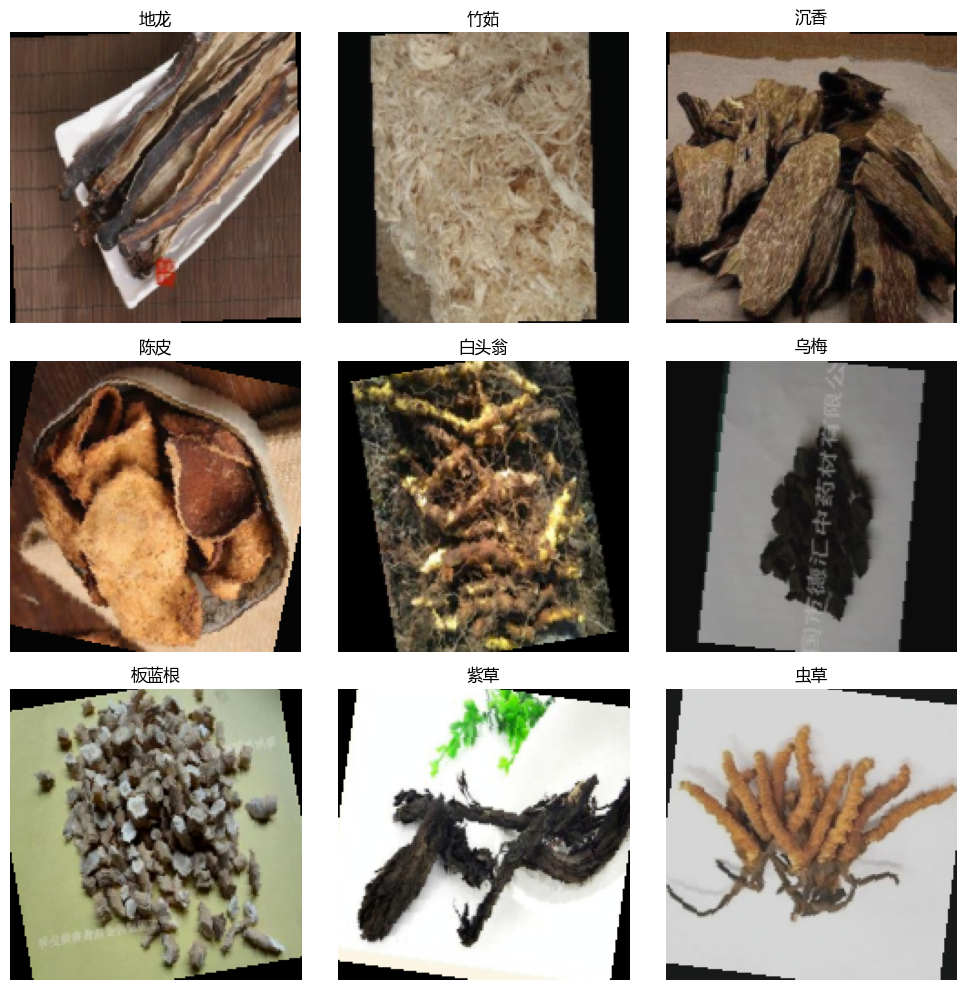

In [12]:
# Visualize a few training images
# Undo normalization only for display
display_images, display_labels = next(iter(train_loader))

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    img = display_images[i].cpu().permute(1, 2, 0).numpy()
    img = np.clip((img * std) + mean, 0, 1)
    plt.imshow(img)
    plt.title(class_names[display_labels[i].item()])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [13]:
# Improved CNN blocks
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout_rate=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),
            nn.Dropout(dropout_rate)
        )

    def forward(self, x):
        return self.block(x)


class ImprovedCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 32, dropout_rate=0.10),
            ConvBlock(32, 64, dropout_rate=0.15),
            ConvBlock(64, 128, dropout_rate=0.20),
            ConvBlock(128, 256, dropout_rate=0.25),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.40),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x


improved_cnn_model = ImprovedCNN(num_classes=num_classes).to(device)
improved_cnn_model

ImprovedCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (7): Dropout(p=0.1, inplace=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps

In [14]:
# Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.Adam(
    improved_cnn_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [15]:
# Training and validation functions
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in tqdm(loader, leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)

In [16]:
# Train loop
improved_cnn_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

improved_cnn_best_val_acc = 0.0
improved_cnn_best_model_wts = copy.deepcopy(improved_cnn_model.state_dict())
improved_cnn_best_model_path = MODELS_DIR / "improved_cnn_pytorch_best_model.pth"

patience_counter = 0

for epoch in range(EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        improved_cnn_model, train_loader, criterion, optimizer, device
    )
    val_loss, val_acc, _, _ = evaluate(
        improved_cnn_model, val_loader, criterion, device
    )

    scheduler.step(val_loss)

    improved_cnn_history["train_loss"].append(train_loss)
    improved_cnn_history["train_acc"].append(train_acc)
    improved_cnn_history["val_loss"].append(val_loss)
    improved_cnn_history["val_acc"].append(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print(f"Learning Rate: {current_lr:.6f}")

    if val_acc > improved_cnn_best_val_acc:
        improved_cnn_best_val_acc = val_acc
        improved_cnn_best_model_wts = copy.deepcopy(improved_cnn_model.state_dict())
        torch.save(improved_cnn_best_model_wts, improved_cnn_best_model_path)
        patience_counter = 0
        print("Best model updated.")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{PATIENCE}")

    print("-" * 60)

    if patience_counter >= PATIENCE:
        print("Early stopping triggered.")
        break

print("Best validation accuracy:", improved_cnn_best_val_acc)
print("Best model saved to:", improved_cnn_best_model_path)

Epoch 1/45


  0%|          | 0/779 [00:00<?, ?it/s]

  0%|          | 0/98 [00:00<?, ?it/s]

Train Loss: 3.1307 | Train Acc: 0.2048
Val   Loss: 2.7437 | Val   Acc: 0.2996
Learning Rate: 0.001000
Best model updated.
------------------------------------------------------------
Epoch 2/45


  0%|          | 0/779 [00:00<?, ?it/s]

...

  0%|          | 0/98 [00:00<?, ?it/s]

Train Loss: 0.9200 | Train Acc: 0.9692
Val   Loss: 0.8797 | Val   Acc: 0.9688
Learning Rate: 0.000250
No improvement. Patience: 1/5
------------------------------------------------------------
Epoch 45/45


  0%|          | 0/779 [00:00<?, ?it/s]

  0%|          | 0/98 [00:00<?, ?it/s]

Train Loss: 0.9196 | Train Acc: 0.9700
Val   Loss: 0.8853 | Val   Acc: 0.9671
Learning Rate: 0.000250
No improvement. Patience: 2/5
------------------------------------------------------------
Best validation accuracy: 0.9717314487632509
Best model saved to: I:\DeepLearning\ChineseHerb_Identify\models\cnn\improved_cnn_pytorch_best_model.pth


In [17]:
# Save training history
improved_cnn_history_df = pd.DataFrame(improved_cnn_history)
improved_cnn_history_path = REPORTS_DIR / "improved_cnn_pytorch_training_history.csv"
improved_cnn_history_df.to_csv(improved_cnn_history_path, index=False)

print("Saved:", improved_cnn_history_path)
improved_cnn_history_df.head()

Saved: I:\DeepLearning\ChineseHerb_Identify\results\reports\improved_cnn_pytorch_training_history.csv


,train_loss,train_acc,val_loss,val_acc
0,3.130669,0.204813,2.743659,0.299550
1,2.662048,0.333795,2.543788,0.363958
2,2.383282,0.430762,2.293712,0.467555
3,2.124181,0.526625,1.934069,0.587376
4,1.931936,0.599587,1.767973,0.651943


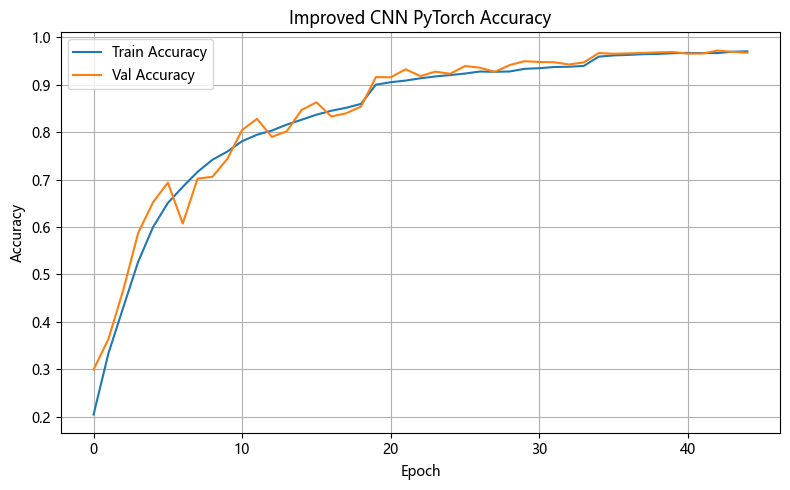

Saved: I:\DeepLearning\ChineseHerb_Identify\results\figures\improved_cnn_pytorch_accuracy_curve.png


In [18]:
# Plot accuracy
plt.figure(figsize=(8, 5))
plt.plot(improved_cnn_history["train_acc"], label="Train Accuracy")
plt.plot(improved_cnn_history["val_acc"], label="Val Accuracy")
plt.title("Improved CNN PyTorch Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

improved_cnn_accuracy_curve_path = FIGURES_DIR / "improved_cnn_pytorch_accuracy_curve.png"
plt.savefig(improved_cnn_accuracy_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", improved_cnn_accuracy_curve_path)

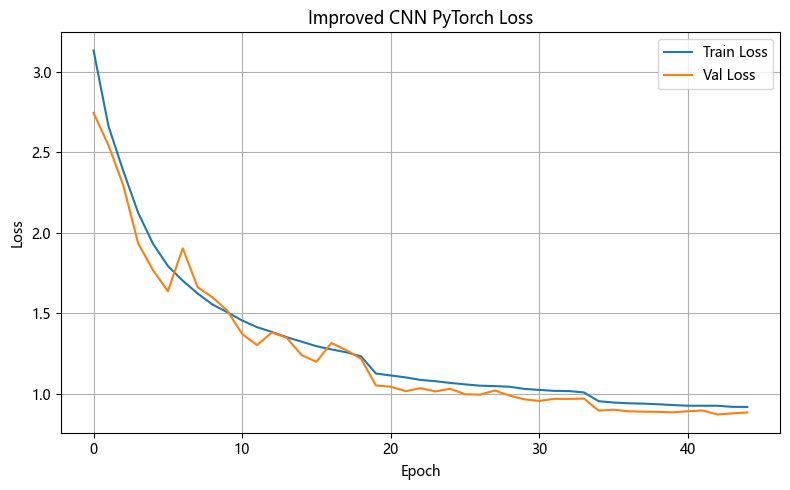

Saved: I:\DeepLearning\ChineseHerb_Identify\results\figures\improved_cnn_pytorch_loss_curve.png


In [19]:
# Plot loss
plt.figure(figsize=(8, 5))
plt.plot(improved_cnn_history["train_loss"], label="Train Loss")
plt.plot(improved_cnn_history["val_loss"], label="Val Loss")
plt.title("Improved CNN PyTorch Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

improved_cnn_loss_curve_path = FIGURES_DIR / "improved_cnn_pytorch_loss_curve.png"
plt.savefig(improved_cnn_loss_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", improved_cnn_loss_curve_path)

In [20]:
# Load best weights before final testing
improved_cnn_model.load_state_dict(torch.load(improved_cnn_best_model_path, map_location=device))
improved_cnn_model.to(device)

ImprovedCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (7): Dropout(p=0.1, inplace=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps

In [21]:
# Test evaluation
improved_cnn_test_loss, improved_cnn_test_acc, improved_cnn_y_true, improved_cnn_y_pred = evaluate(
    improved_cnn_model, test_loader, criterion, device
)

print(f"Improved CNN Test Loss: {improved_cnn_test_loss:.4f}")
print(f"Improved CNN Test Accuracy: {improved_cnn_test_acc:.4f}")

  0%|          | 0/98 [00:00<?, ?it/s]

Improved CNN Test Loss: 0.8632
Improved CNN Test Accuracy: 0.9771


In [22]:
# Classification report
improved_cnn_report_dict = classification_report(
    improved_cnn_y_true,
    improved_cnn_y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

improved_cnn_report_df = pd.DataFrame(improved_cnn_report_dict).transpose()
improved_cnn_report_path = REPORTS_DIR / "improved_cnn_pytorch_classification_report.csv"
improved_cnn_report_df.to_csv(improved_cnn_report_path, encoding="utf-8-sig")

print("Saved:", improved_cnn_report_path)
improved_cnn_report_df.head(10)

Saved: I:\DeepLearning\ChineseHerb_Identify\results\reports\improved_cnn_pytorch_classification_report.csv


,precision,recall,f1-score,support
乌梅,1.000000,0.991803,0.995885,122.0
侧柏叶,0.990826,0.964286,0.977376,112.0
北沙参块,0.991667,0.975410,0.983471,122.0
北沙参条,0.973214,0.990909,0.981982,110.0
半夏,0.973684,0.956897,0.965217,116.0
地龙,0.984962,1.000000,0.992424,131.0
夏枯草,0.990826,0.981818,0.986301,110.0
大血藤,1.000000,1.000000,1.000000,132.0
小茴香,0.961832,0.969231,0.965517,130.0
巴戟天,0.992593,0.964029,0.978102,139.0


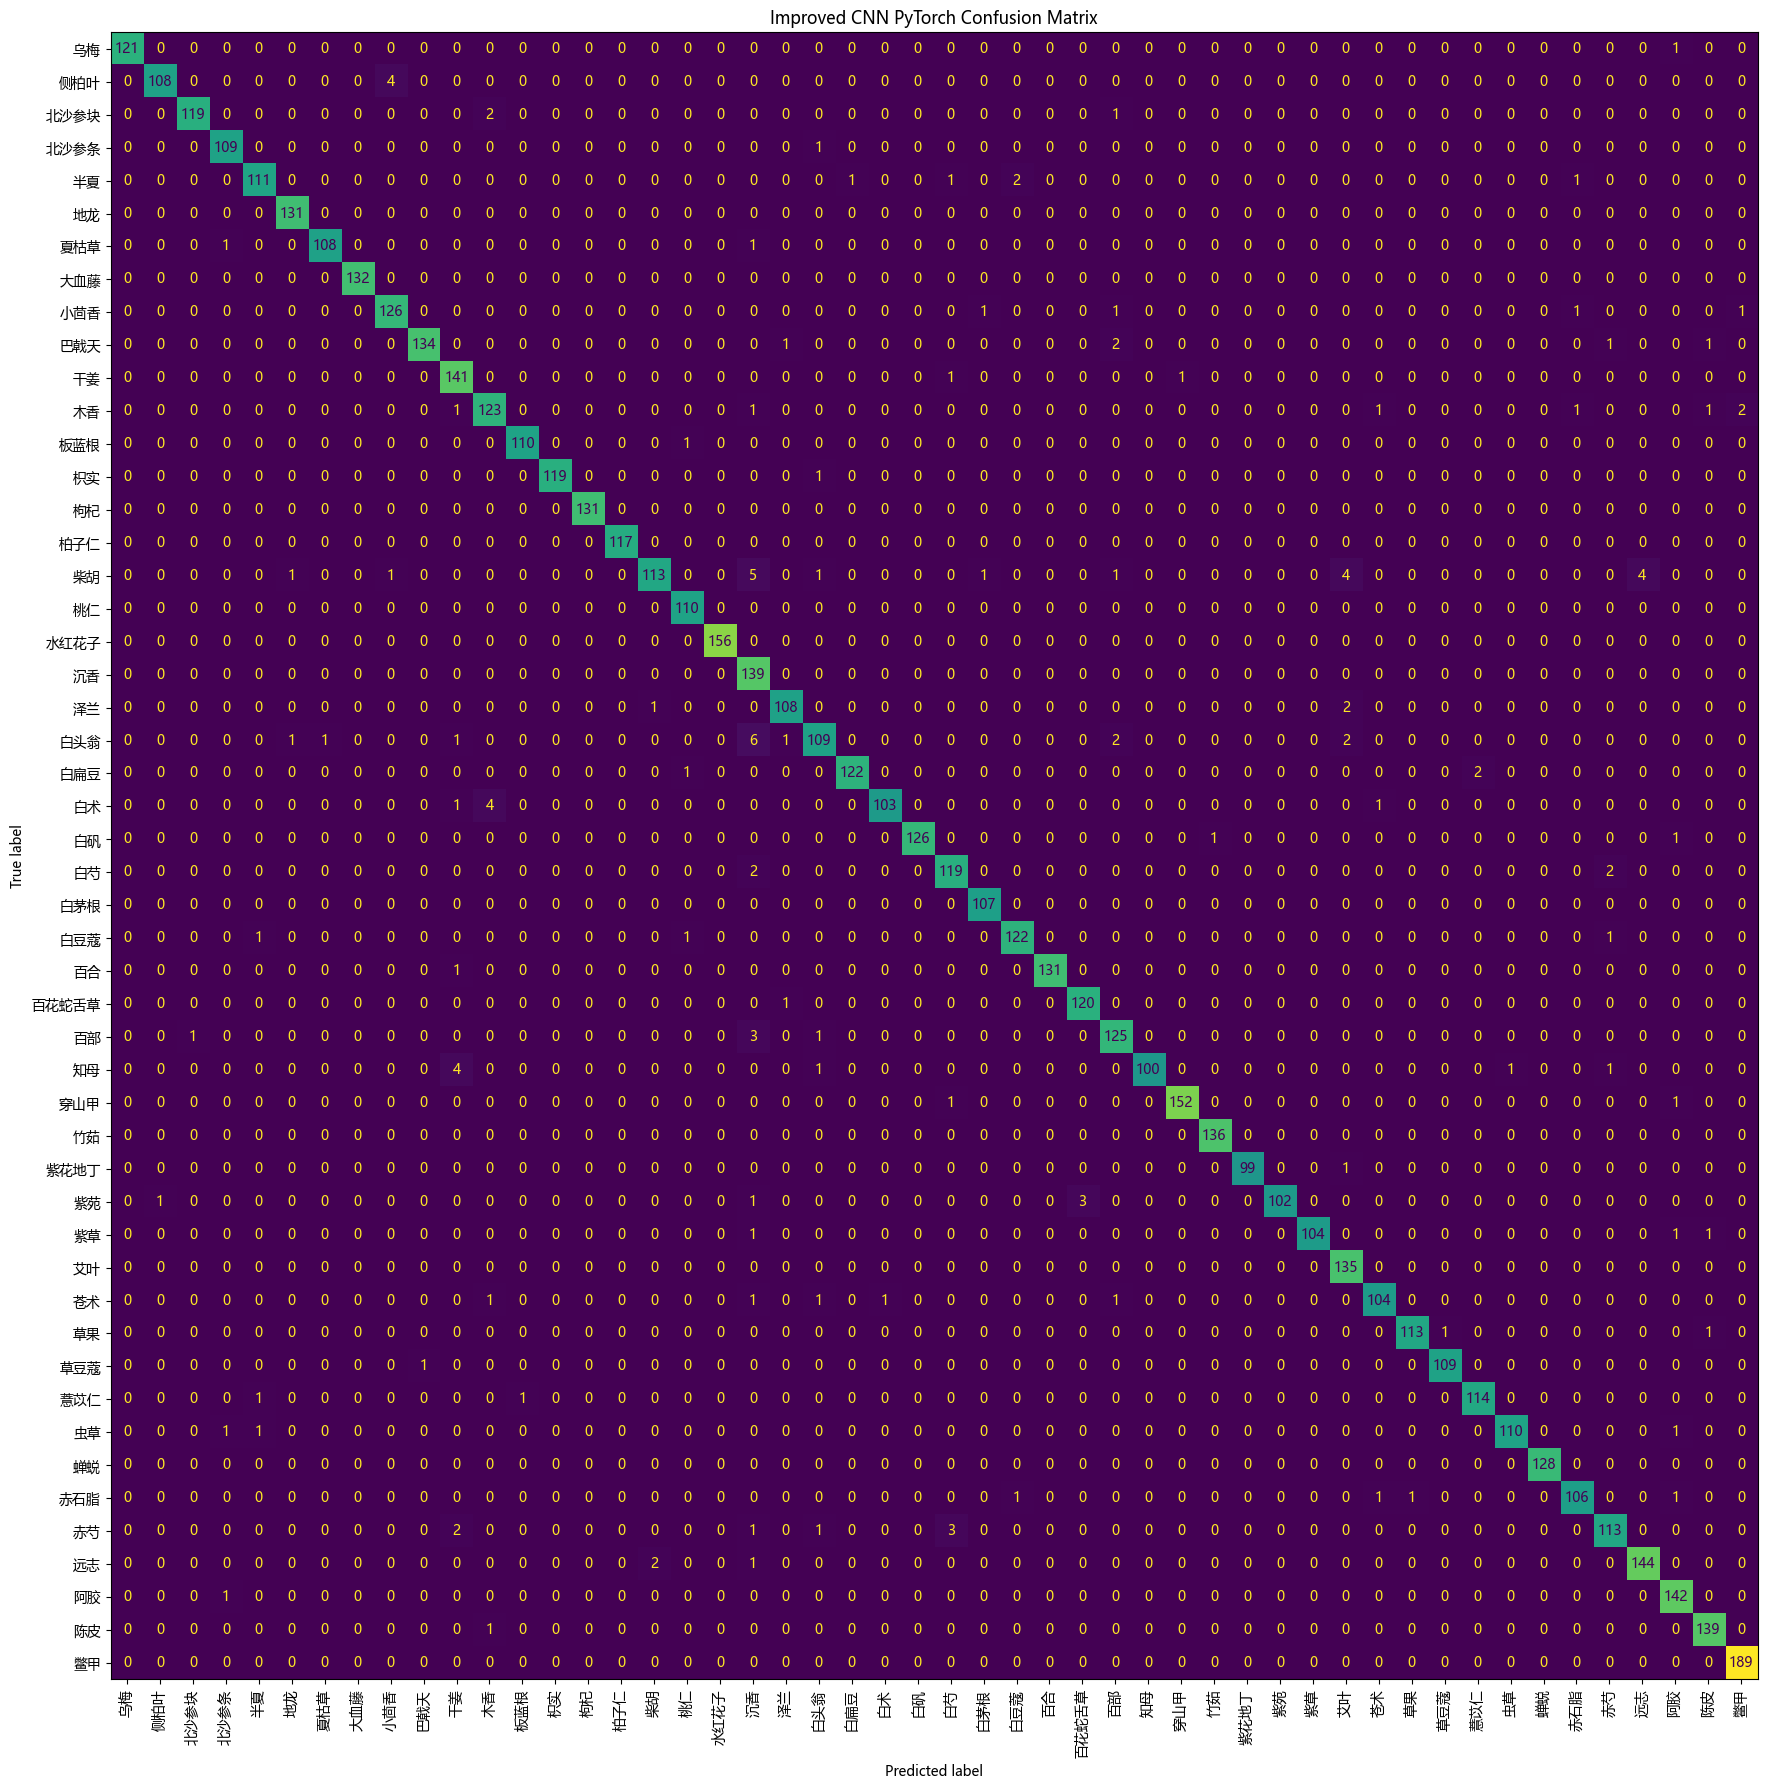

Saved: I:\DeepLearning\ChineseHerb_Identify\results\figures\improved_cnn_pytorch_confusion_matrix.png


In [23]:
# Confusion matrix
improved_cnn_cm = confusion_matrix(improved_cnn_y_true, improved_cnn_y_pred)

fig, ax = plt.subplots(figsize=(18, 18))
disp = ConfusionMatrixDisplay(
    confusion_matrix=improved_cnn_cm,
    display_labels=class_names
)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("Improved CNN PyTorch Confusion Matrix")
plt.tight_layout()

improved_cnn_confusion_matrix_path = FIGURES_DIR / "improved_cnn_pytorch_confusion_matrix.png"
plt.savefig(improved_cnn_confusion_matrix_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", improved_cnn_confusion_matrix_path)

In [24]:
# Save summary
improved_cnn_summary = {
    "model_name": "improved_cnn_pytorch",
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs_requested": EPOCHS,
    "epochs_completed": len(improved_cnn_history["train_loss"]),
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "num_classes": num_classes,
    "best_val_accuracy": float(max(improved_cnn_history["val_acc"])),
    "best_val_loss": float(min(improved_cnn_history["val_loss"])),
    "test_loss": float(improved_cnn_test_loss),
    "test_accuracy": float(improved_cnn_test_acc),
    "device": str(device)
}

improved_cnn_summary_path = REPORTS_DIR / "improved_cnn_pytorch_summary.json"
with open(improved_cnn_summary_path, "w", encoding="utf-8") as f:
    json.dump(improved_cnn_summary, f, ensure_ascii=False, indent=4)

print("Saved:", improved_cnn_summary_path)
improved_cnn_summary

Saved: I:\DeepLearning\ChineseHerb_Identify\results\reports\improved_cnn_pytorch_summary.json


{'model_name': 'improved_cnn_pytorch',
 'image_size': 160,
 'batch_size': 64,
 'epochs_requested': 45,
 'epochs_completed': 45,
 'learning_rate': 0.001,
 'weight_decay': 0.0001,
 'num_classes': 50,
 'best_val_accuracy': 0.9717314487632509,
 'best_val_loss': 0.8724459950425332,
 'test_loss': 0.8631541337985282,
 'test_accuracy': 0.9770539152759948,
 'device': 'cuda'}

## Notes for report writing

This notebook can be described as an **improved CNN model** because it extends the baseline with:
- deeper convolutional blocks
- batch normalization
- adaptive average pooling
- stronger augmentation
- dropout
- weight decay
- label smoothing
- validation-based checkpointing

This makes it a stronger second CNN experiment before transfer learning.
